In [3]:
import numpy as np
import pandas as pd
import seaborn as sns

# The AB test to check the real impact of a medicine

In [4]:
a = np.array([23, 21, 19, 24, 35, 17, 18, 24, 33, 27, 21, 23])
b = np.array([31, 28, 19, 24, 32, 27, 16, 41, 23, 32, 29, 33])
#datasets
#a get a fake medicine
#b a real medicine
#each monthh 100 people take that
#sets suggest the treatment statistics

In [5]:
a_mean = a.mean()
b_mean = b.mean()
d = round(((b_mean) - (a_mean)),2)
print(f'A mean :{a_mean} people monthly \nB mean :{b_mean:.2f} people monthly')
print(f'difference between the sets {d}')
print("the question is whether it's by chance or not?")

A mean :23.75 people monthly 
B mean :27.92 people monthly
difference between the sets 4.17
the question is whether it's by chance or not?


In [6]:
sales = np.array([
    np.append(np.zeros(len(a)), np.ones(len(b))),
    np.append(a, b)
])
sales_t = sales.T

In [8]:
def sh_exp(N):
    ''' n times make random numbers and repeat the process '''
    experiment_diff_mean = np.empty([N, 1])
    for times in np.arange(N):
        experiment_label = np.random.randint(0, 2, len(sales_t))
        experiment_data = np.array([
            experiment_label,
            sales_t[:, 1]
        ]).T
        experiment_diff_mean[times] = experiment_data[experiment_data[:, 0] == 1][:, 1].mean() - experiment_data[experiment_data[:, 0] == 0][:, 1].mean()
    return experiment_diff_mean

e10 = sh_exp(1000)
print(e10)

[[ 1.37815126]
 [ 2.16666667]
 [ 1.86666667]
 [-1.31468531]
 [ 4.33333333]
 [-0.02797203]
 [-1.16666667]
 [ 4.22377622]
 [ 1.83333333]
 [-2.22222222]
 [-0.0625    ]
 [ 3.14285714]
 [ 2.16666667]
 [-2.125     ]
 [ 0.91428571]
 [-2.54545455]
 [-0.13986014]
 [ 1.77142857]
 [ 3.46666667]
 [ 0.33333333]
 [ 6.22857143]
 [-0.44444444]
 [ 1.68888889]
 [ 3.46218487]
 [-4.17142857]
 [ 3.33333333]
 [ 2.51428571]
 [ 0.4       ]
 [-1.87412587]
 [ 2.16666667]
 [-0.08888889]
 [-0.77310924]
 [ 0.28571429]
 [-2.16666667]
 [ 0.8       ]
 [ 0.02797203]
 [-1.98601399]
 [-0.6993007 ]
 [ 0.4       ]
 [ 4.67132867]
 [ 1.65714286]
 [-2.8       ]
 [-0.28571429]
 [-0.16666667]
 [ 4.33566434]
 [-0.81118881]
 [-3.875     ]
 [-2.22222222]
 [ 2.83333333]
 [ 6.83333333]
 [-4.22857143]
 [ 1.37062937]
 [-0.44444444]
 [ 7.25      ]
 [ 1.14685315]
 [ 0.        ]
 [ 0.64335664]
 [ 4.39160839]
 [-1.        ]
 [-1.5       ]
 [-4.        ]
 [ 0.36363636]
 [ 4.20168067]
 [ 1.77142857]
 [-2.5       ]
 [ 2.20979021]
 [-0.22857

In [9]:
print('the number of experiments where the difference was the same  or greater')
print(f'{len(e1 [e1 >= d])} times')
print(f'{(len(e1 [e1 >= d])) / 1000 * 100} %')
#the lower  percentage shows a lower  probability of the even occuring by chance

the number of experiments where the difference was the same  or greater
56 times
5.6000000000000005 %


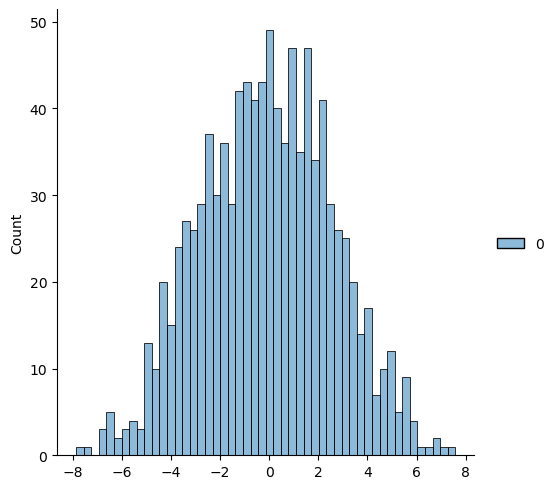

In [10]:
sns . displot(e1 , bins = 50)

# AB testing the new website page vs. the old page

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [12]:
df = pd.read_csv('ab_data.csv')
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [13]:
print(df.shape, 'dimensions','\n')
print(round(df['converted'].mean(),3) , 'Average of converted in total','\n')
print(df.nunique(), 'unique numbers')

(294478, 5) dimensions 

0.12 Average of converted in total 

user_id         290584
timestamp       294478
group                2
landing_page         2
converted            2
dtype: int64 unique numbers


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


## data preparation

In [15]:
df.query('group == "treatment" and landing_page != "new_page"')

,user_id,timestamp,group,landing_page,converted
308,857184,2017-01-20 07:34:59.832626,treatment,old_page,0
327,686623,2017-01-09 14:26:40.734775,treatment,old_page,0
357,856078,2017-01-12 12:29:30.354835,treatment,old_page,0
685,666385,2017-01-23 08:11:54.823806,treatment,old_page,0
713,748761,2017-01-10 15:47:44.445196,treatment,old_page,0
...,...,...,...,...,...
293773,688144,2017-01-16 20:34:50.450528,treatment,old_page,1
293817,876037,2017-01-17 16:15:08.957152,treatment,old_page,1
293917,738357,2017-01-05 15:37:55.729133,treatment,old_page,0
294014,813406,2017-01-09 06:25:33.223301,treatment,old_page,0


In [16]:
df.query('group == "control" and landing_page != "old_page"')

,user_id,timestamp,group,landing_page,converted
22,767017,2017-01-12 22:58:14.991443,control,new_page,0
240,733976,2017-01-11 15:11:16.407599,control,new_page,0
490,808613,2017-01-10 21:44:01.292755,control,new_page,0
846,637639,2017-01-11 23:09:52.682329,control,new_page,1
850,793580,2017-01-08 03:25:33.723712,control,new_page,1
...,...,...,...,...,...
293894,741581,2017-01-09 20:49:03.391764,control,new_page,0
293996,942612,2017-01-08 13:52:28.182648,control,new_page,0
294200,928506,2017-01-13 21:32:10.491309,control,new_page,0
294253,886135,2017-01-06 12:49:20.509403,control,new_page,0


In [17]:
df2t = df.query('group == "treatment" and landing_page == "new_page"')
df2c = df.query('group == "control" and landing_page == "old_page"')
df2 = df2t.merge(df2c, how='outer')
df2.head()

,user_id,timestamp,group,landing_page,converted
0,630000,2017-01-19 06:26:06.548941,treatment,new_page,0
1,630001,2017-01-16 03:16:42.560309,treatment,new_page,1
2,630002,2017-01-19 19:20:56.438330,control,old_page,0
3,630003,2017-01-12 10:09:31.510471,treatment,new_page,0
4,630004,2017-01-18 20:23:58.824994,treatment,new_page,0


In [18]:
df2.shape

(290585, 5)

In [19]:
df2.describe()

,user_id,converted
count,290585.000000,290585.000000
mean,788004.825246,0.119597
std,91224.582639,0.324490
min,630000.000000,0.000000
25%,709035.000000,0.000000
50%,787995.000000,0.000000
75%,866956.000000,0.000000
max,945999.000000,1.000000


In [20]:
df2.nunique()

user_id         290584
timestamp       290585
group                2
landing_page         2
converted            2
dtype: int64

In [21]:
sum(df2['user_id'].duplicated())

1

In [22]:
df2[df2['user_id'].duplicated(keep='first')]

,user_id,timestamp,group,landing_page,converted
131713,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


In [23]:
df2 = df2[~df2.user_id.duplicated(keep='first')]

In [24]:
df2.nunique()

user_id         290584
timestamp       290584
group                2
landing_page         2
converted            2
dtype: int64

In [25]:
df2_control = df2.query('group == "control"')
df2_treamtment = df2.query('group == "treatment"')
control_mean =df2_control['converted'].mean() * 100
treatment_mean = df2_treamtment['converted'].mean() * 100
print(round(df2['converted'].mean(),5), 'average in total')
print(control_mean , 'control average')
print(treatment_mean , 'treatment average')

0.1196 average in total
12.03863045004612 control average
11.880806551510565 treatment average


### new design meaningfully decreased sales? (using AB test)

In [26]:
print(f'{df2_control['converted'].mean() * 100} % converted average for control group')
print(f'{df2_treamtment['converted'].mean() * 100} % converted average for treatment group')
print(f'{df2['converted'].mean()} average of converted')
print(f'{1 - df2['converted'].mean()} not converted average')
print(f'{len(df2_treamtment)} treatment group length')

12.03863045004612 % converted average for control group
11.880806551510565 % converted average for treatment group
0.11959708724499628 average of converted
0.8804029127550037 not converted average
145310 treatment group length


In [39]:
new_page_converted = np.random.choice([1, 0], size=len(df2_treamtment), p=[df2.converted.mean(), (1 - df2.converted.mean())])

(array([127805.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,  17505.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

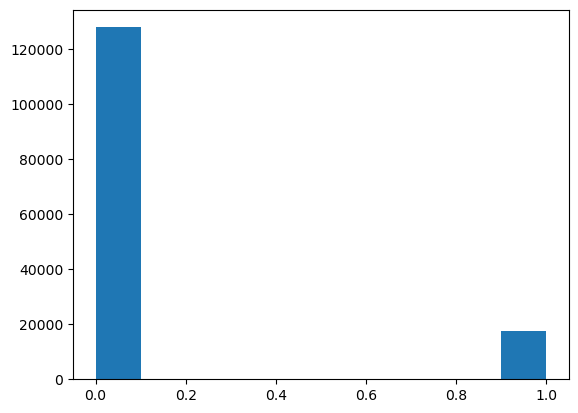

In [40]:
plt.hist(new_page_converted)

In [48]:
old_page_converted = np.random.choice([1, 0], size=len(df2_control), p=[df2.converted.mean(), (1 - df2.converted.mean())])

In [49]:
new_page_converted = np.random.binomial(len(df2_treamtment), df2.converted.mean(), 10000) / len(df2_treamtment)
#10000repetition

In [50]:
old_page_converted = np.random.binomial(len(df2_control), df2.converted.mean(), 10000) / len(df2_control)

In [51]:
p_diffs = new_page_converted - old_page_converted
p_diffs.mean()

np.float64(-2.4057889770134844e-06)

In [52]:
ab_data_diff = df2_treamtment['converted'].mean() - df2_control['converted'].mean()

In [53]:
(p_diffs > ab_data_diff).mean() * 100

np.float64(90.63)

In [56]:
(p_diffs < ab_data_diff).mean() * 100
#p value = 9% the probability that this event occured by chaance

np.float64(9.370000000000001)

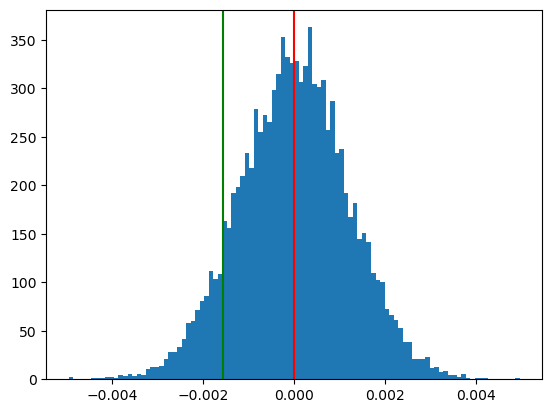

In [57]:
plt.hist(p_diffs, bins=100)
low = ab_data_diff
higth = p_diffs.mean()
plt.axvline(x=low, color='g')
plt.axvline(x=higth, color='r')

# T-Test
## the new fertilizer's effect on crops
### t-test is used for normal distributions|

In [32]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import math
import pickle

In [33]:
df = pd.read_csv('orange_trees.csv')
df.head()

,tree_number,oranges
0,1223,305.470796
1,1224,208.357224
2,1225,318.145987
3,1226,274.531146
4,1227,245.627474


<Axes: >

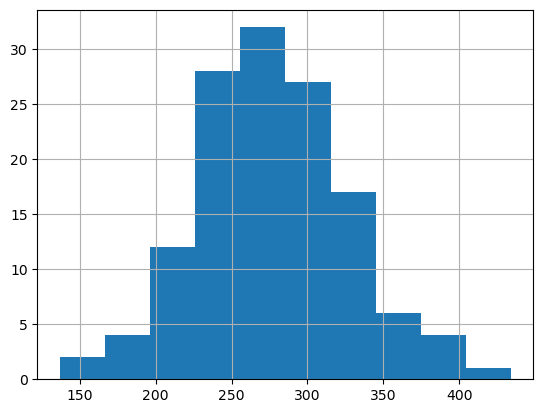

In [34]:
df['oranges'].hist(bins=10)

In [35]:
df.describe()

,tree_number,oranges
count,133.00000,133.000000
mean,1289.00000,277.852803
std,38.53786,50.922243
min,1223.00000,137.023145
25%,1256.00000,237.696112
50%,1289.00000,279.470482
75%,1322.00000,312.079787
max,1355.00000,434.025714


In [36]:
population_mean = 271.93
# yearly mean in total

In [37]:
#1 sample ,test one sample with the population
stats.ttest_1samp(a=df['oranges'], popmean=population_mean)
#p value = 18%

TtestResult(statistic=np.float64(1.3413606837344207), pvalue=np.float64(0.18210666026278088), df=np.int64(132))

In [38]:
population_mean = 3.2
type(population_mean)

float

## Which country's IELTS test takers achieved higher scores?(T-test independent <2-sample>)

In [40]:
df_ielts_98 = pd.read_csv('ielts_IR.csv')
df_ielts_99 = pd.read_csv('ielts_IRQ.csv')

<Axes: >

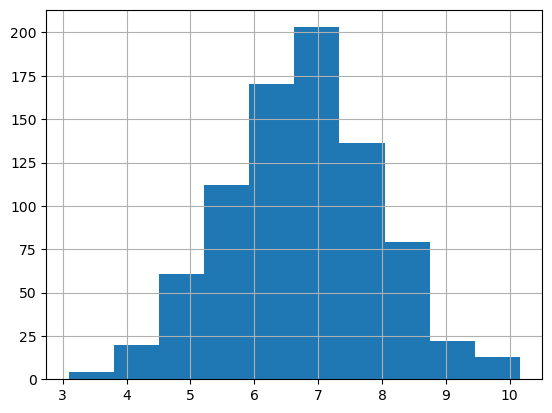

In [41]:
df_ielts_98['ielts'].hist()

<Axes: >

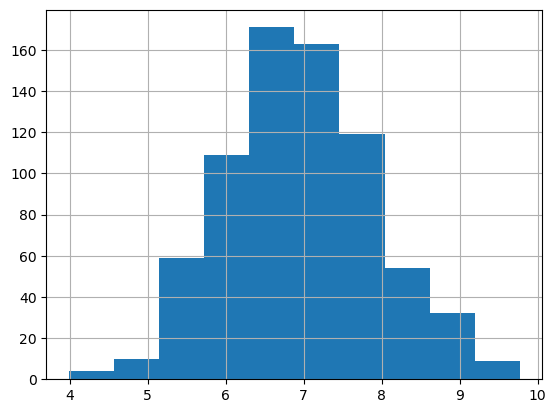

In [42]:
df_ielts_99['ielts'].hist()

In [43]:
df_ielts_98.describe()

,student_code,ielts
count,820.000000,820.000000
mean,279326.500000,6.754804
std,236.857904,1.178691
min,278917.000000,3.094945
25%,279121.750000,5.971638
50%,279326.500000,6.775687
75%,279531.250000,7.532372
max,279736.000000,10.159504


In [44]:
df_ielts_99.describe()

,student_code,ielts
count,7.300000e+02,730.000000
mean,3.141476e+06,6.956215
std,2.108771e+02,0.964884
min,3.141112e+06,3.988457
25%,3.141294e+06,6.302632
50%,3.141476e+06,6.912297
75%,3.141659e+06,7.617062
max,3.141841e+06,9.772641


In [46]:
stats.ttest_ind(a=df_ielts_98['ielts'], b=df_ielts_99['ielts'])
#Given the small t-test value, there is a high probability that the difference is significant

TtestResult(statistic=np.float64(-3.6538217675570297), pvalue=np.float64(0.00026698442613130104), df=np.float64(1548.0))

## The tablet's effect on weight loss

In [48]:
df = pd.read_csv('weights_change.csv')
df.head()

,weight_before,weight_after
0,65.126024,69.579014
1,67.081931,70.142003
2,72.380314,67.482958
3,63.592077,64.890133
4,57.333414,70.430886


array([[<Axes: title={'center': 'weight_before'}>,
        <Axes: title={'center': 'weight_after'}>]], dtype=object)

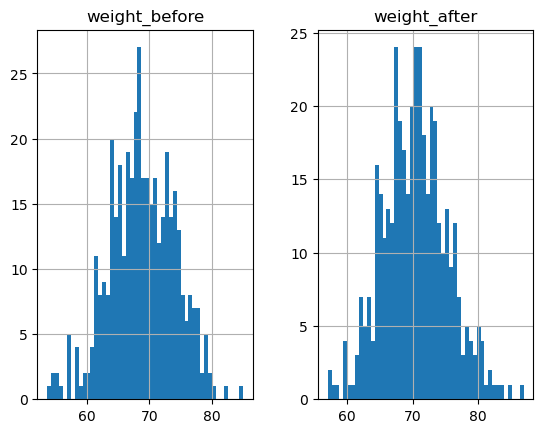

In [49]:
df.hist(bins=50)

In [50]:
df.describe()

,weight_before,weight_after
count,410.000000,410.000000
mean,68.863354,70.425341
std,5.243526,4.975498
min,53.647173,56.991774
25%,65.136296,67.184292
50%,68.669384,70.455450
75%,72.729821,73.506856
max,85.056591,86.939716


In [51]:
stats.ttest_rel(a=df['weight_before'], b=df['weight_after'])

TtestResult(statistic=np.float64(-4.4624675042842386), pvalue=np.float64(1.0488324309628723e-05), df=np.int64(409))

In [52]:
#Given the small t-test value, there is a high probability that the difference is significant

# U-test
### used for data that don't follow a normal distribution

In [9]:
from scipy import stats
import numpy as np

In [15]:
# two classes' grades distributions
# Are there statistically significant differences between the groups?
g1 = [20, 23, 21, 25, 18, 17, 18, 24, 20, 24]
g2 = [24, 25, 21, 22, 23, 28, 24, 27, 21, 23]

In [16]:
print(np.mean(g1))
print(np.mean(g2))

21.0
23.8


In [17]:
stats.mannwhitneyu(g1, g2, alternative='two-sided')
#difference in groups

MannwhitneyuResult(statistic=np.float64(24.5), pvalue=np.float64(0.05679033417444351))

In [20]:
stats.mannwhitneyu(g1, g2, alternative='greater')
#probability of g11 being greater 

MannwhitneyuResult(statistic=np.float64(24.5), pvalue=np.float64(0.9762109730290699))

In [21]:
stats.mannwhitneyu(g1, g2, alternative='less')

MannwhitneyuResult(statistic=np.float64(24.5), pvalue=np.float64(0.028395167087221757))

# Chi2

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [33]:
#finding a relationship between two non-numeric variables
#a meaningfull relation between the fields?
data = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [25]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [28]:
data.isnull().any()

Age                         False
Attrition                   False
BusinessTravel              False
DailyRate                   False
Department                  False
DistanceFromHome            False
Education                   False
EducationField              False
EmployeeCount               False
EmployeeNumber              False
EnvironmentSatisfaction     False
Gender                      False
HourlyRate                  False
JobInvolvement              False
JobLevel                    False
JobRole                     False
JobSatisfaction             False
MaritalStatus               False
MonthlyIncome               False
MonthlyRate                 False
NumCompaniesWorked          False
Over18                      False
OverTime                    False
PercentSalaryHike           False
PerformanceRating           False
RelationshipSatisfaction    False
StandardHours               False
StockOptionLevel            False
TotalWorkingYears           False
TrainingTimesL

In [29]:
data['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [30]:
data['JobSatisfaction'].value_counts()

JobSatisfaction
4    459
3    442
1    289
2    280
Name: count, dtype: int64

In [32]:
ct = pd.crosstab(data['Attrition'], data['JobSatisfaction'], margins=True)
ct

JobSatisfaction,1,2,3,4,All
Attrition,,,,,
No,223,234,369,407,1233
Yes,66,46,73,52,237
All,289,280,442,459,1470
